In [4]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((494, 19277), (123, 19277), (494,), (123,))


Calculating SHAP values...
SHAP values shape: (123, 19277, 5)
Total features: 19277

=== Overall Top 10 Features ===
         Feature  MeanAbsSHAP_MaxAcrossSubtypes
5407     SLC26A1                       0.005885
3857      HOXD10                       0.005612
7896      AKR1B1                       0.005461
7141     FAM217A                       0.005313
8868   LOC727677                       0.005081
11563    PIK3C2A                       0.004844
9145        STAR                       0.004807
17020      UHRF1                       0.004620
13065        ANG                       0.004507
15140     SEPT12                       0.004462


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


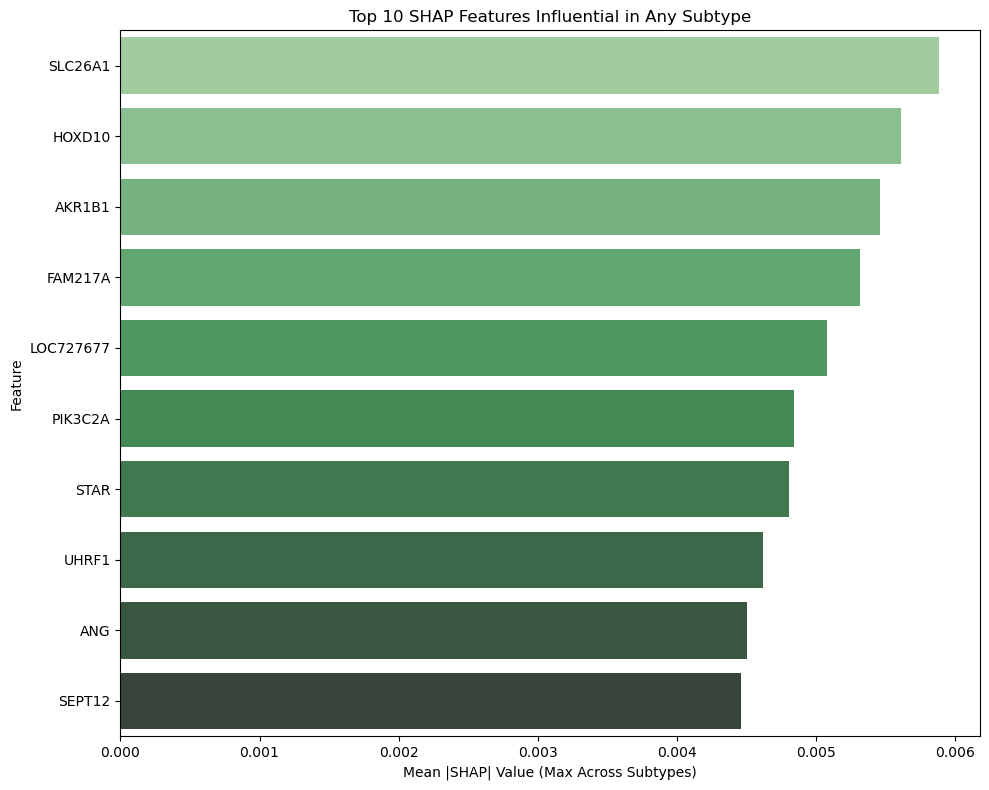

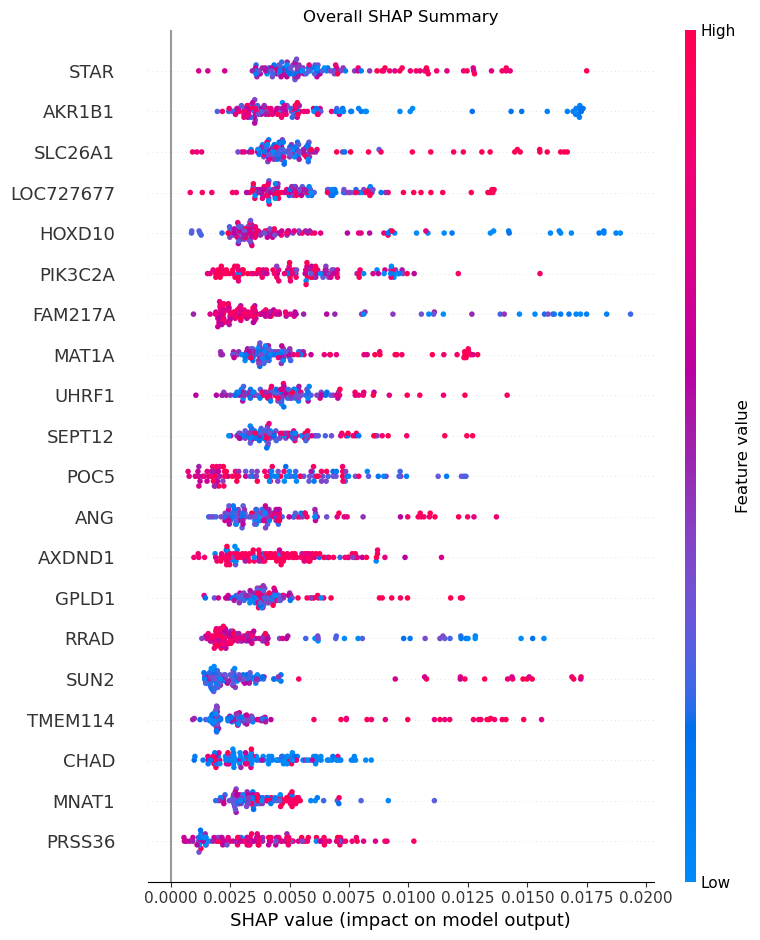


Subtype 1: Basal
         Feature  MeanAbsSHAP
5407     SLC26A1     0.005885
8868   LOC727677     0.005081
9145        STAR     0.004807
17020      UHRF1     0.004620
13065        ANG     0.004507
15140     SEPT12     0.004462
18932     IL17RA     0.003810
15103  LOC440335     0.003666
6629       GPLD1     0.003662
10466      RGS10     0.003469


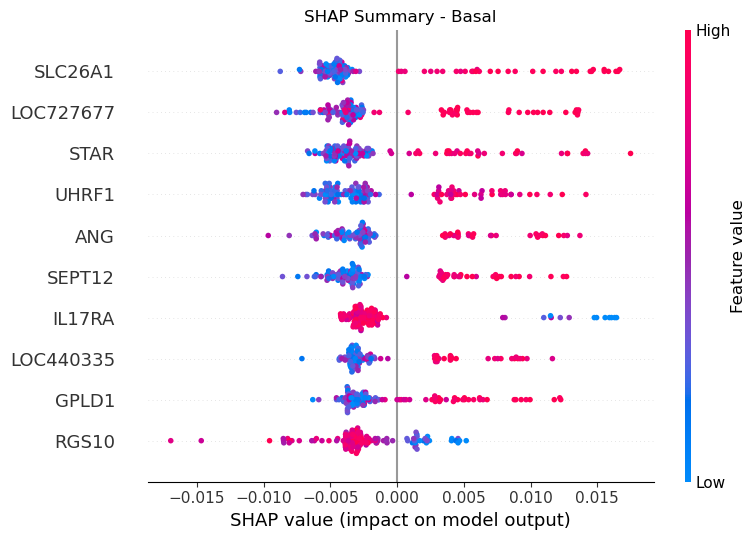

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


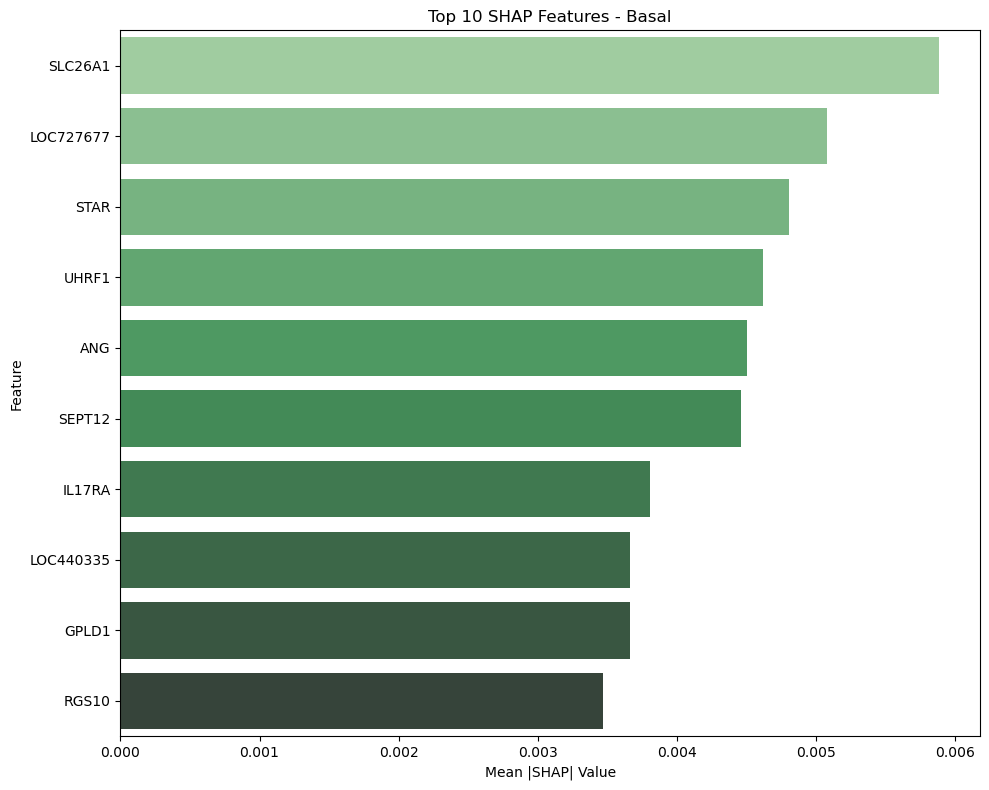


Subtype 2: Her2
       Feature  MeanAbsSHAP
11563  PIK3C2A     0.004253
15943     CHAD     0.003519
1628    AXDND1     0.003245
5792      POC5     0.003027
6184    ZNF366     0.002881
16765    LYPD4     0.002869
15211   PRSS36     0.002867
998      PRUNE     0.002861
17375    GPR77     0.002838
16339   LGALS9     0.002774


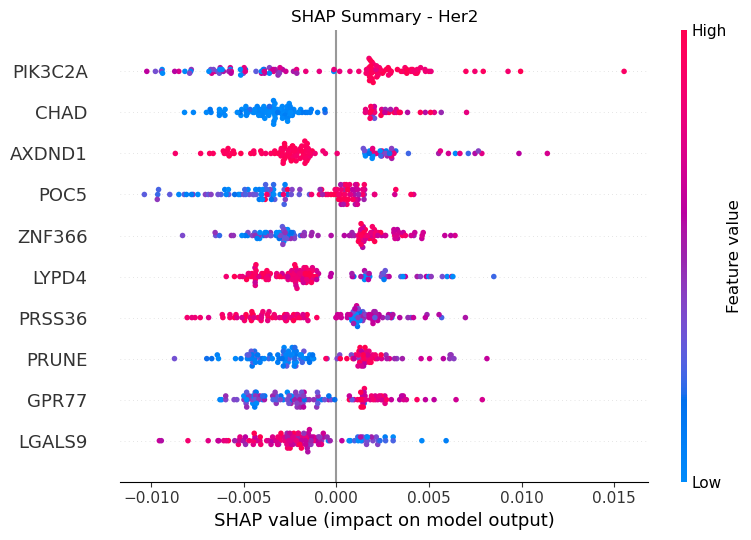

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


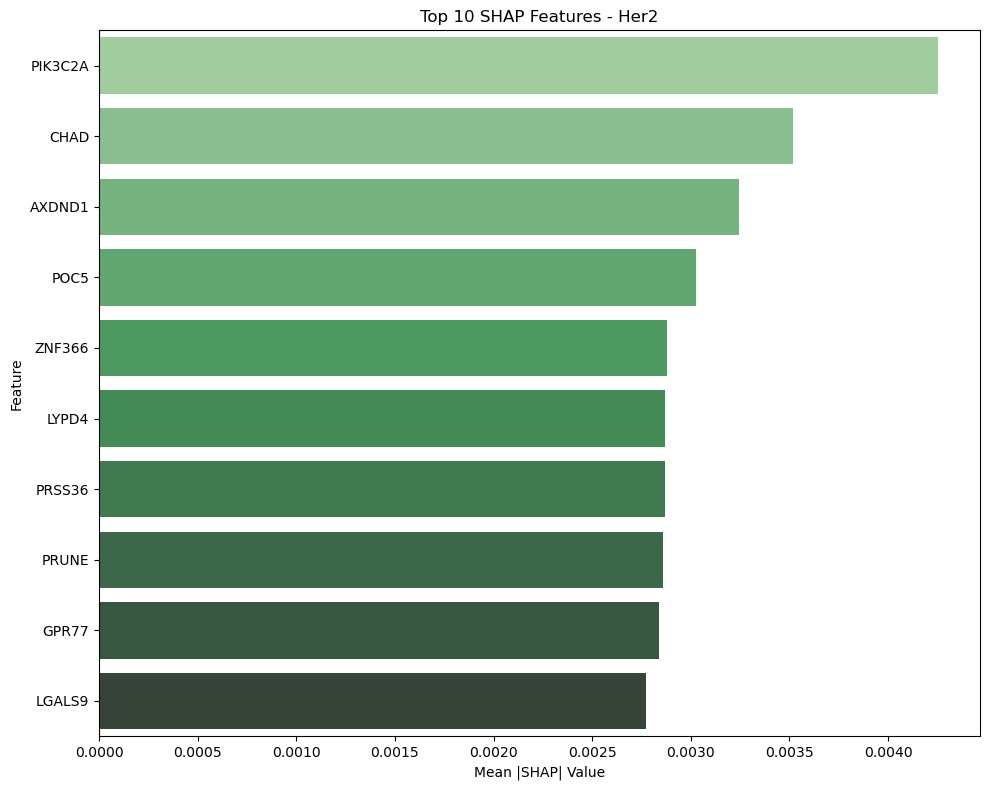


Subtype 3: LumA
         Feature  MeanAbsSHAP
1628      AXDND1     0.004178
8868   LOC727677     0.004105
9145        STAR     0.003832
15211     PRSS36     0.003374
10284      IFIT2     0.003244
15943       CHAD     0.003039
15140     SEPT12     0.002938
8509      OSGIN2     0.002795
8591   TNFRSF10A     0.002780
16276       PIGS     0.002775


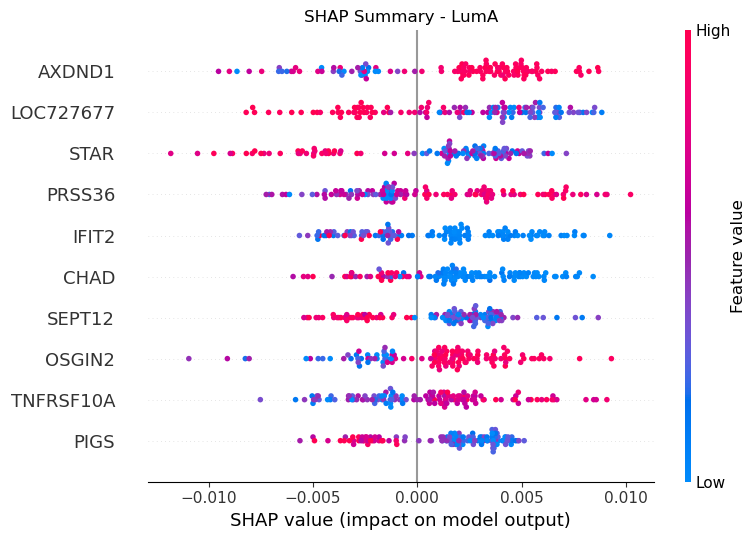

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


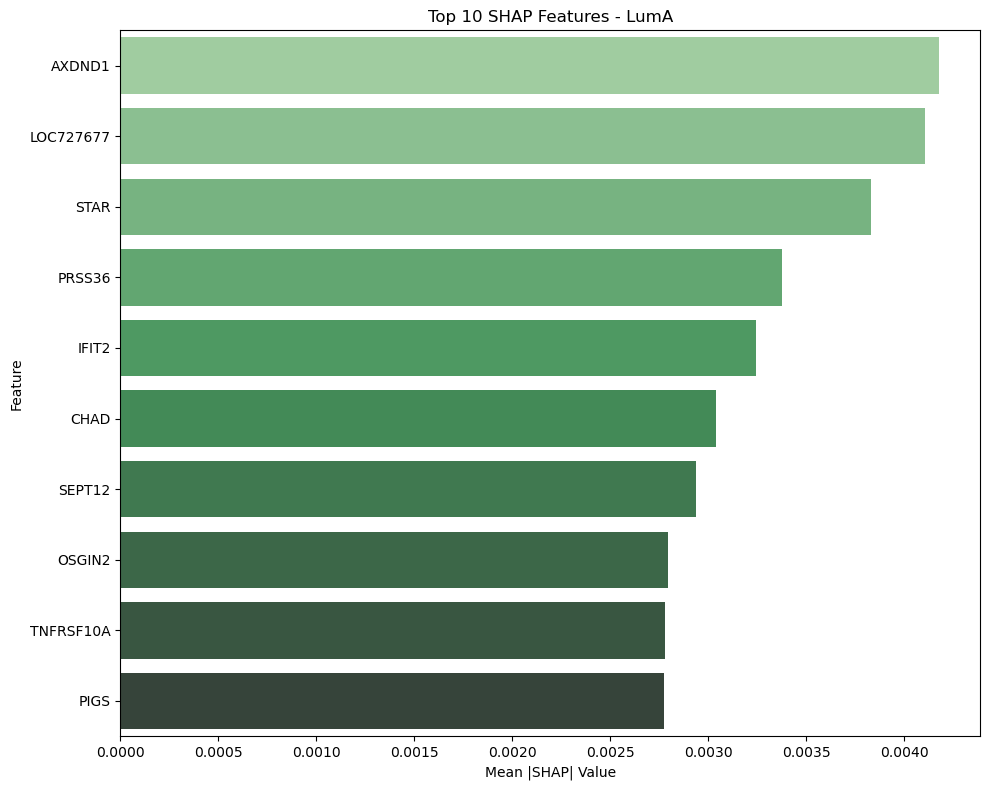


Subtype 4: LumB
       Feature  MeanAbsSHAP
11563  PIK3C2A     0.004844
9145      STAR     0.003872
5792      POC5     0.003638
7896    AKR1B1     0.003450
17020    UHRF1     0.002890
998      PRUNE     0.002645
9937     MAT1A     0.002604
13715    MNAT1     0.002523
6629     GPLD1     0.002517
7924    AHCYL2     0.002456


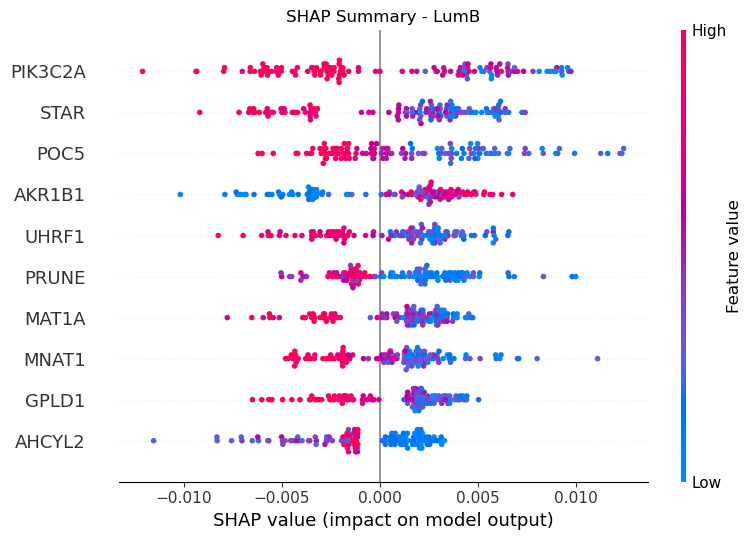

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


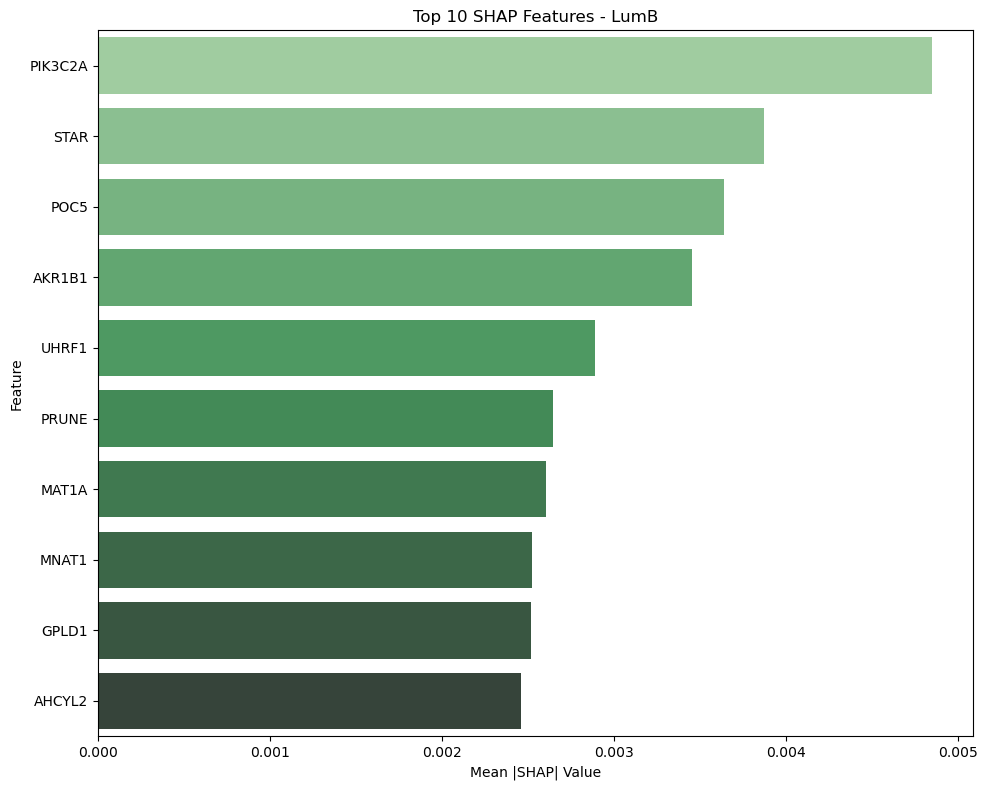


Subtype 5: Normal
       Feature  MeanAbsSHAP
3857    HOXD10     0.005612
7896    AKR1B1     0.005461
7141   FAM217A     0.005313
9145      STAR     0.004725
9937     MAT1A     0.004234
14792  TMEM114     0.004188
14683     RRAD     0.004086
19192     SUN2     0.004082
5710   PCDHGB4     0.003218
8240    CLDN15     0.003160


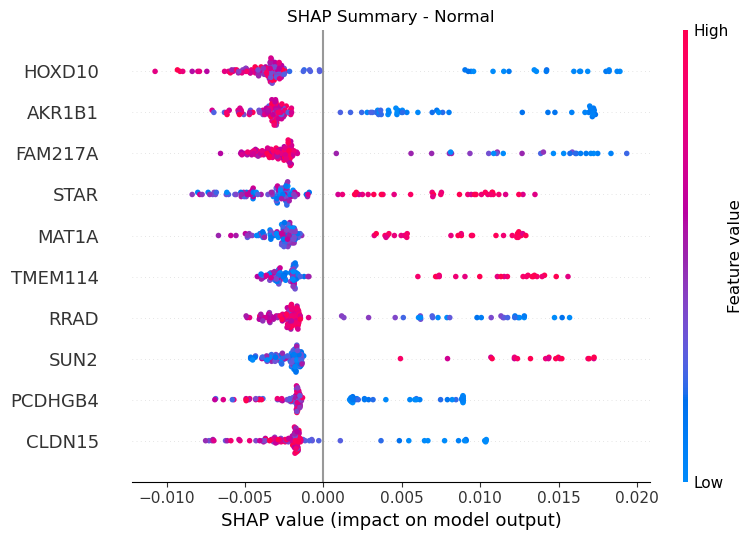

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_2140\3327671600.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


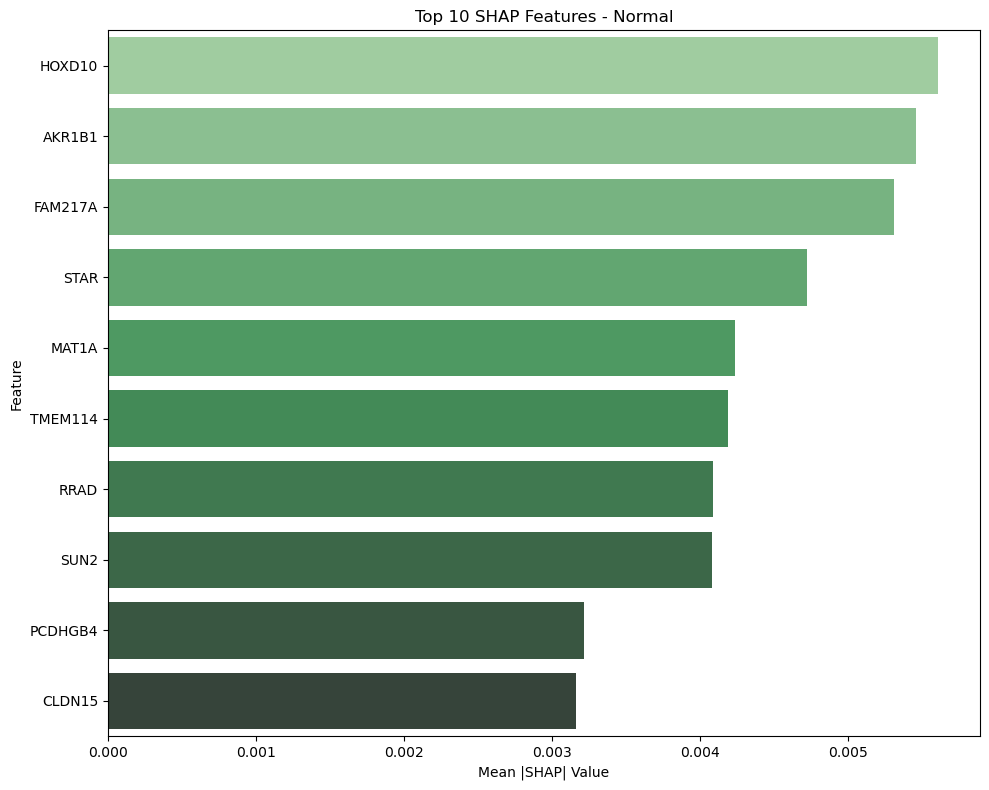


SHAP analysis complete — both overall and per-subtype results generated.


In [6]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_TCGA_IP_SMOTE_No_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
feature_names = np.array(X_test.columns)

# Scale test set
X_test_scaled = scaler.transform(X_test)

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Total features: {len(feature_names)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall,
    X_test_scaled,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_

for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": feature_names,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class,
        X_test_scaled,
        feature_names=feature_names,
        max_display=10,
        show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")